# Quickstart: NOAA HRRR forecast, 18 hour, virtual - dynamical.org Icechunk Zarr

NOAA's High-Resolution Rapid Refresh (HRRR) is a convection-allowing weather model covering the contiguous United States at 3 km resolution. At that resolution it resolves individual thunderstorms, which makes it the go-to model in the US for severe weather, snow bands, and other fine-scale phenomena. This dataset provides the 18-hour forecasts, initialized every hour, from July 2018 to present, transformed into an analysis-ready cloud-optimized Icechunk Zarr by [dynamical.org](https://dynamical.org).

Dataset documentation: https://dynamical.org/catalog/noaa-hrrr-forecast-18-hour-virtual/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy rioxarray metpy plotly

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("noaa-hrrr-forecast-18-hour-virtual", chunks=None)
ds

<xarray.Dataset> Size: 3PB
Dimensions:                                                          (
                                                                      init_time: 70492,
                                                                      lead_time: 19,
                                                                      y: 1059,
                                                                      x: 1799)
Coordinates:
  * init_time                                                        (init_time) datetime64[ns] 564kB ...
    expected_forecast_length                                         (init_time) timedelta64[us] 564kB ...
  * lead_time                                                        (lead_time) timedelta64[us] 152B ...
    valid_time                                                       (init_time, lead_time) datetime64[ns] 11MB ...
  * y                                                                (y) float64 8kB ...
  * x                                                                (x) float64 14kB ...
    latitude                                                         (y, x) float32 8MB ...
    longitude                                                        (y, x) float32 8MB ...
    spatial_ref                                                      int64 8B ...
Data variables: (12/142)
    categorical_freezing_rain_surface                                (init_time, lead_time, y, x) float64 20TB ...
    brightness_temperature_channel_114                               (init_time, lead_time, y, x) float64 20TB ...
    best_4_layer_lifted_index_180_0mb                                (init_time, lead_time, y, x) float64 20TB ...
    aerosol_optical_thickness_atmosphere                             (init_time, lead_time, y, x) float64 20TB ...
    categorical_ice_pellets_surface                                  (init_time, lead_time, y, x) float64 20TB ...
    baseflow_groundwater_runoff_surface                              (init_time, lead_time, y, x) float64 20TB ...
    ...                                                               ...
    wind_u_10m                                                       (init_time, lead_time, y, x) float64 20TB ...
    wind_u_80m                                                       (init_time, lead_time, y, x) float64 20TB ...
    wind_v_80m                                                       (init_time, lead_time, y, x) float64 20TB ...
    wind_gust_surface                                                (init_time, lead_time, y, x) float64 20TB ...
    wind_v_10m                                                       (init_time, lead_time, y, x) float64 20TB ...
    visible_diffuse_downward_solar_flux_surface                      (init_time, lead_time, y, x) float64 20TB ...
Attributes:
    dataset_id:           noaa-hrrr-forecast-18-hour-virtual
    dataset_version:      0.1.0
    name:                 NOAA HRRR forecast, 18 hour, virtual
    description:          Weather forecasts from the High-Resolution Rapid Re...
    attribution:          NOAA NWS NCEP HRRR data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Continental United States
    spatial_resolution:   3 km
    time_domain:          Forecasts initialized 2018-07-13 12:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every hour
    forecast_domain:      Forecast lead time 0-18 hours ahead
    forecast_resolution:  Hourly

This is a forecast dataset with two time dimensions: `init_time` (when the forecast run began) and `lead_time` (how far ahead the forecast extends). The `valid_time` coordinate combines these to give the actual forecasted time.

HRRR is distributed on a 3 km Lambert Conformal grid, so cells are indexed by projected `x` / `y` coordinates, with 2-D `latitude` / `longitude` coordinates and a coordinate reference system attached. Variables are split into three groups: **surface** (at the root, opened by default), **pressure_level**, and **model_level**. We start with surface fields and open the vertical groups further down.

### A simulated radar mosaic

HRRR's signature field is the model's simulated radar, composite reflectivity. Because it resolves individual storms, a single forecast time step reads like a real radar scan. Here is the 21 May 2024 outbreak that produced the devastating Greenfield, Iowa tornado. HRRR is one of our best tools for anticipating devastating events like this.

Text(0.5, 1.0, '')

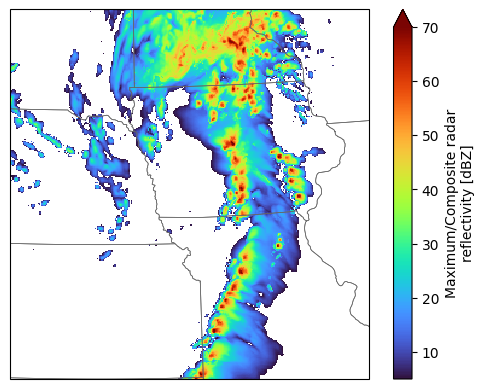

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray  # enables the .rio accessor

# create a cartopy CRS for HRRR's native Lambert Conformal grid using the dataset's metadata
crs = ds.spatial_ref.attrs
hrrr_proj = ccrs.LambertConformal(
    central_longitude=crs["longitude_of_central_meridian"],
    central_latitude=crs["latitude_of_projection_origin"],
    standard_parallels=crs["standard_parallel"],
    globe=ccrs.Globe(semimajor_axis=crs["semi_major_axis"], semiminor_axis=crs["semi_minor_axis"]),
)

refl = (
    ds["composite_reflectivity"]
    .sel(init_time="2024-05-21T18", lead_time="4h")
    .rio.clip_box(-100, 37, -90, 45, crs="EPSG:4326")
    .load()
)

ax = plt.subplot(projection=hrrr_proj)
refl.where(refl > 5).plot(ax=ax, transform=hrrr_proj, cmap="turbo", vmin=5, vmax=70)
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
ax.set_title("")

### A forecast at a point

To read a time series we convert a longitude/latitude into the dataset's projected `x` / `y` grid. This run, initialized as a powerful storm system crossed the Plains on 14 March 2025, captures a sharp cold-frontal passage at Kansas City: the dew point collapses into the dry slot behind the front, and the temperature follows.

For clipping to regions or polygons, see the `noaa-hrrr-forecast-48-hour.ipynb`.

Note that for this access pattern the materialized (rechunked, non-virtual) [NOAA HRRR forecast, 48 hour](https://dynamical.org/catalog/noaa-hrrr-forecast-48-hour/) would be faster, but the virtual product works fine as well.

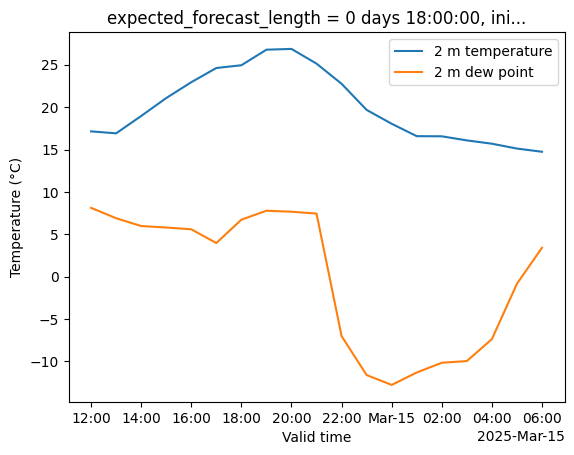

In [4]:
from pyproj import Transformer

to_xy = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x, y = to_xy.transform(-94.58, 39.10)  # Kansas City, MO

kc = ds.sel(init_time="2025-03-14T12", x=x, y=y, method="nearest")
kc["temperature_2m"].plot(x="valid_time", label="2 m temperature")
kc["dew_point_temperature_2m"].plot(x="valid_time", label="2 m dew point")
plt.ylabel("Temperature (°C)")
plt.legend()

### Deaccumulating precipitation

HRRR reports precipitation as a running total accumulated since `init_time`. To recover a precipitation rate (matching the materialized dataset's `precipitation_surface` in mm/s) we difference the accumulation along `lead_time` and divide by the step in seconds. Here is Hurricane Milton's rain over Tampa: the running total climbs past 130 mm while the hourly rate marks each burst.

(0.0, 39.942)

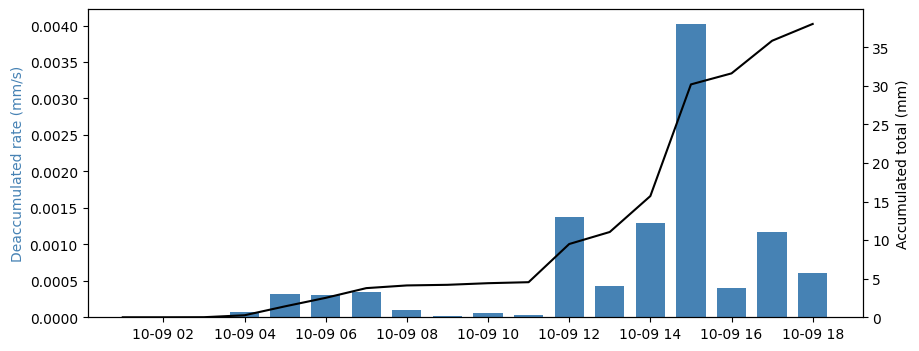

In [5]:
import numpy as np

x, y = to_xy.transform(-82.46, 27.95)  # Tampa, FL

# Convert accumulated precipitation to precipitation rate
accum = ds["total_precipitation_run_total_surface"].sel(init_time="2024-10-09T00", x=x, y=y, method="nearest")
step_s = ds.lead_time.diff("lead_time") / np.timedelta64(1, "s")
precipitation_surface = accum.diff("lead_time") / step_s

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(precipitation_surface.valid_time, precipitation_surface, width=0.03, color="steelblue")
ax.set_ylabel("Deaccumulated rate (mm/s)", color="steelblue")
right = ax.twinx()
right.plot(accum.valid_time, accum, color="black")
right.set_ylabel("Accumulated total (mm)")
right.set_ylim(bottom=0)

### What did the atmosphere look like before the storm?

The `pressure_level` group carries the full vertical profile — temperature, humidity, and wind on 39 pressure levels — everything needed for a skew-T log-P diagram, the forecaster's standard tool for judging instability and wind shear. We open the group, pull a column at a point in the Greenfield inflow, and hand it to [MetPy](https://unidata.github.io/MetPy/).

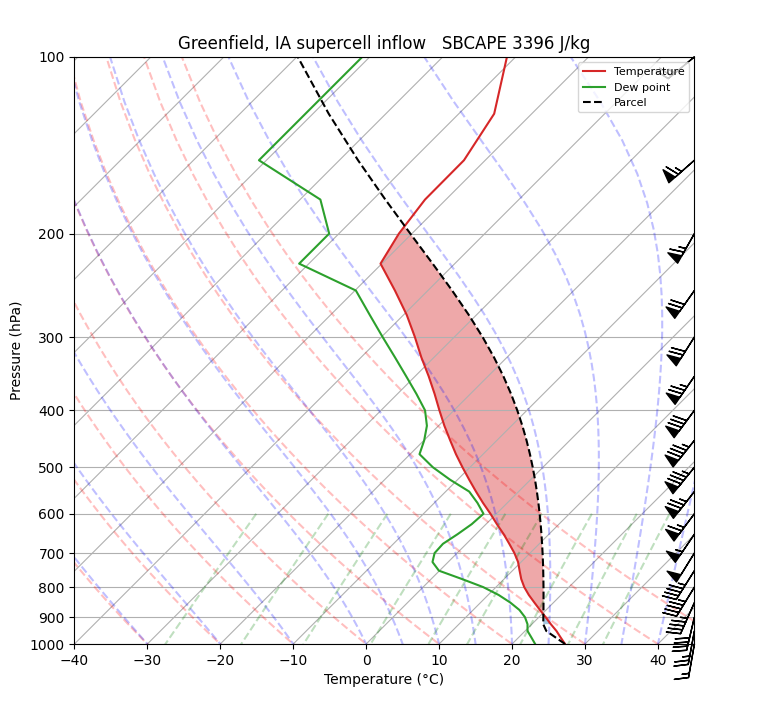

In [6]:
import numpy as np
from metpy.units import units
from metpy.plots import SkewT
import metpy.calc as mpcalc

ds_pressure = dynamical_catalog.open("noaa-hrrr-forecast-18-hour-virtual", group="pressure_level", chunks=None)

def sounding(lat, lon, init, lead, title):
    x, y = to_xy.transform(lon, lat)
    prof = (
        ds_pressure[["temperature", "dew_point_temperature", "wind_u", "wind_v", "geopotential_height"]]
        .sel(init_time=init, lead_time=lead).sel(x=x, y=y, method="nearest").load()
    )

    p = prof.pressure_level.values
    T, Td = prof.temperature.values, prof.dew_point_temperature.values
    u, v = prof.wind_u.values, prof.wind_v.values
    z = prof.geopotential_height.values
    m = np.isfinite(T) & np.isfinite(Td) & np.isfinite(u) & np.isfinite(v)  # drop below-ground levels
    p, T, Td, u, v, z = (a[m] for a in (p, T, Td, u, v, z))

    p, T, Td = p * units.hPa, T * units.degC, Td * units.degC
    u, v = (u * units("m/s")).to("knots"), (v * units("m/s")).to("knots")
    parcel = mpcalc.parcel_profile(p, T[0], Td[0]).to("degC")
    cape, _ = mpcalc.surface_based_cape_cin(p, T, Td)

    skew = SkewT(plt.figure(figsize=(8, 9)), rotation=45)
    skew.plot(p, T, "tab:red", label="Temperature")
    skew.plot(p, Td, "tab:green", label="Dew point")
    skew.plot(p, parcel, "k", ls="--", label="Parcel")
    skew.shade_cape(p, T, parcel)
    skew.shade_cin(p, T, parcel, Td)
    skew.plot_barbs(p[::2], u[::2], v[::2])
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    skew.ax.set(ylim=(1000, 100), xlim=(-40, 45), xlabel="Temperature (°C)", ylabel="Pressure (hPa)")
    skew.ax.set_title(f"{title}   SBCAPE {cape.m:.0f} J/kg")
    skew.ax.legend(loc="upper right", fontsize=8)

# 21 May 2024, ~1 h before the Greenfield, IA EF4 tornado
sounding(41.0, -94.0, "2024-05-21T18", "3h", "Greenfield, IA supercell inflow")

### The storm in three dimensions

The pressure-level fields also reconstruct a storm's full 3D shape. Summing the cloud and precipitation mixing ratios over a region and drawing the result as an isosurface reveals the convective towers of the Greenfield supercells rising past 10 km. Drag to orbit, scroll to zoom.

In [7]:
import plotly.graph_objects as go

# One forecast hour over the storm
storm = (
    ds_pressure[["graupel", "snow_mixing_ratio", "cloud_mixing_ratio", "rain_mixing_ratio", "geopotential_height"]]
    .sel(init_time="2024-05-21T18", lead_time="3h", pressure_level=slice(1000, 150))
    .rio.clip_box(-96, 39, -92, 43, crs="EPSG:4326")
    .coarsen(x=4, y=4, boundary="trim").mean()
    .interp(pressure_level=np.arange(1000, 150, -10))
    .load()
)
condensate = (storm.graupel + storm.snow_mixing_ratio + storm.cloud_mixing_ratio + storm.rain_mixing_ratio) * 1000  # g/kg
height_km = storm.geopotential_height.mean(["x", "y"]) / 1000
X, Y, Z = np.meshgrid(storm.x, storm.y, height_km, indexing="ij")

fig = go.Figure(go.Isosurface(
    x=X.ravel(), y=Y.ravel(), z=Z.ravel(),
    value=condensate.transpose("x", "y", "pressure_level").values.ravel(),
    isomin=0.2, isomax=4, surface_count=3, opacity=0.3, colorscale="ice",
    caps=dict(x_show=False, y_show=False, z_show=False),
))
fig.update_layout(scene=dict(aspectratio=dict(x=1.5, y=1.5, z=1), zaxis_title="height (km)"))
fig.show()

### Where did HRRR forecast storms to rotate?

`maximum_updraft_helicity_3000_0m` measures mid-level updraft rotation, a proxy for supercells and tornado potential. Taking its maximum across the whole 18-hour forecast traces a "swath" wherever the model spun up a rotating storm. For the 14–15 March 2025 outbreak — the largest March outbreak on record — the swaths line up as long parallel tracks across Missouri, Illinois, and the Deep South.

Text(0.5, 1.0, '')

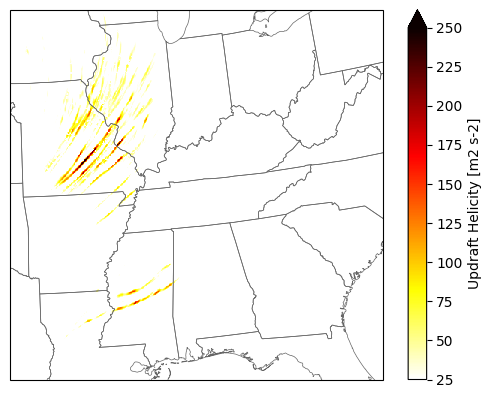

In [8]:
uh = (
    ds["maximum_updraft_helicity_3000_0m"]
    .sel(init_time="2025-03-14T12")
    .rio.clip_box(-95, 30, -80, 42, crs="EPSG:4326")
    .max("lead_time")
)
ax = plt.subplot(projection=hrrr_proj)
uh.where(uh > 25).plot(ax=ax, transform=hrrr_proj, cmap="hot_r", vmin=25, vmax=250)
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
ax.set_title("")

### Animated: Hurricane Milton's landfall

At 3 km, an hourly forecast loop resolves the fine structure of a landfalling hurricane. This run, initialized 9 October 2024, follows Milton's eye and spiral bands sweeping across west-central Florida.

In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

milton = (
    ds["composite_reflectivity"]
    .sel(init_time="2024-10-09T00")
    .rio.clip_box(-88, 24, -79, 31, crs="EPSG:4326")
    .coarsen(x=4, y=4, boundary="trim").mean()
    .load()
)
milton = milton.where(milton > 5)

fig, ax = plt.subplots(figsize=(7, 6), dpi=72, subplot_kw={"projection": hrrr_proj})
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
ax.coastlines(linewidth=0.5)
mesh = milton.isel(lead_time=0).plot(ax=ax, transform=hrrr_proj, cmap="turbo", vmin=5, vmax=70)

def update(i):
    mesh.set_array(milton.isel(lead_time=i).values.ravel())
    ax.set_title(str(milton.valid_time.isel(lead_time=i).values)[:13])

anim = FuncAnimation(fig, update, frames=milton.sizes["lead_time"], interval=200)
plt.close(fig)
HTML(anim.to_jshtml())

/Users/marsh/workspace/dynamical-org/notebooks/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


### Community challenge

HRRR's 3 km convection-allowing grid, refreshed every hour, is built for fine-scale, high-impact weather. A few directions to explore:

- **Hail and wind swaths.** Like the updraft-helicity swath above, take the 18-hour maximum of `maximum_hail_diameter_surface` or `wind_gust_surface` over a severe-weather day and map where the worst conditions were forecast.
- **Solar power ramps.** `downward_short_wave_radiation_flux_surface` at hourly resolution captures cloud-driven dips in solar generation. Pick a solar-heavy region and find the steepest forecast ramp.
- **Forecast vs. reality.** Compare a forecast field against the companion [NOAA HRRR analysis](https://dynamical.org/catalog/noaa-hrrr-analysis/) dataset at matching valid times to see how the 18-hour forecast verified.

For zonal statistics over polygons (states, watersheds, service territories), see [xvec](https://xvec.readthedocs.io/) and the [NOAA HRRR forecast 48-hour quickstart](https://dynamical.org/catalog/noaa-hrrr-forecast-48-hour/).